In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/muhammadbinimran/housing-price-prediction-data/housing_price_dataset.csv")

df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


No. of rows and columns

In [27]:
df.shape

(50000, 6)

Datasets information 

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


Describe the stastical summary

In [29]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


check if there is any null value or not

In [30]:
df.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

check if there is any duplicated values or not

In [31]:
df.duplicated().sum()

np.int64(0)

Shows Distribution

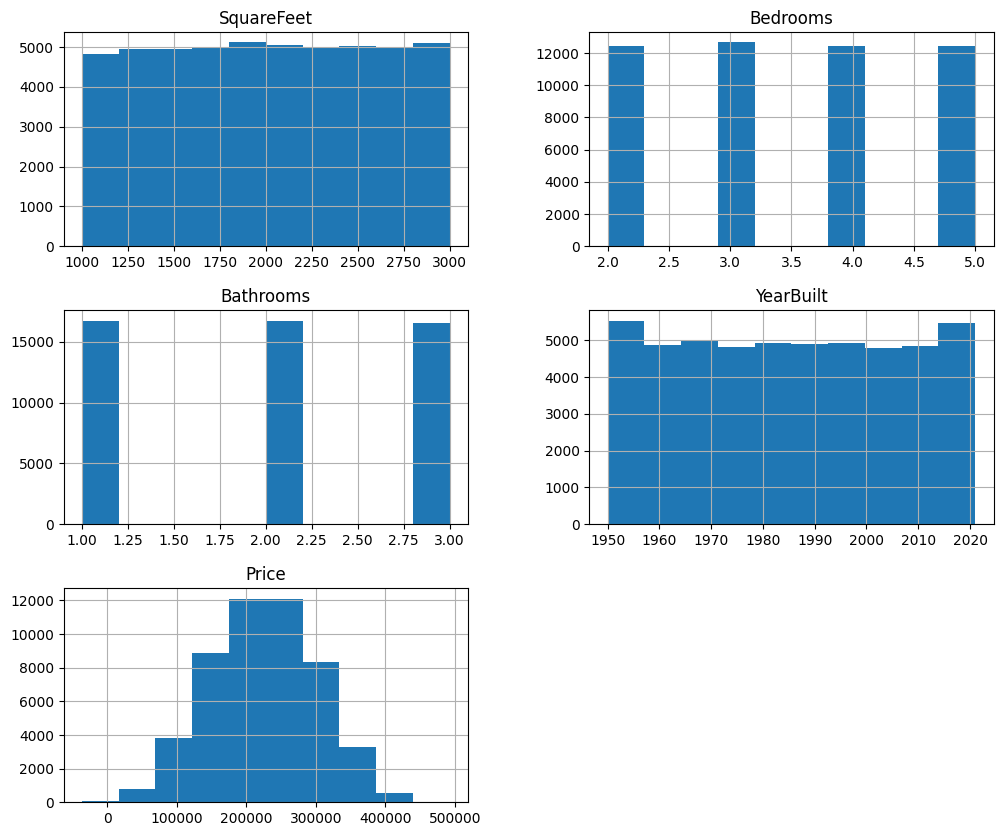

In [32]:
df.hist(figsize=(12,10))
plt.show()

Detect outlier using Box-plot methord

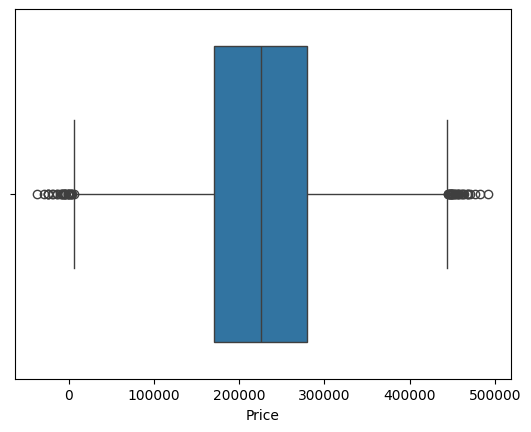

In [33]:
sns.boxplot(x=df["Price"])
plt.show()

Most house prices fall roughly between 180,000 and 280,000.

The median price appears around 230,000.

There are outliers on both sides:

Very cheap houses near 0–50k

Very expensive houses around 450k–500k

In [34]:
df[df["Price"]> 450000]

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
2845,2999,5,2,Urban,1999,461502.014630
3285,2985,5,1,Rural,1961,456959.804367
3357,2928,3,3,Suburb,1962,457902.675442
3784,2901,2,3,Urban,1996,470989.679074
3967,2931,5,1,Rural,1983,453551.125469
7276,2957,2,3,Rural,1989,452870.618989
7430,2758,5,2,Rural,1967,492195.259972
11322,2888,2,2,Urban,1953,468470.378004
12055,2888,5,1,Suburb,2016,451173.373568
21815,2998,3,2,Urban,1995,468493.877841


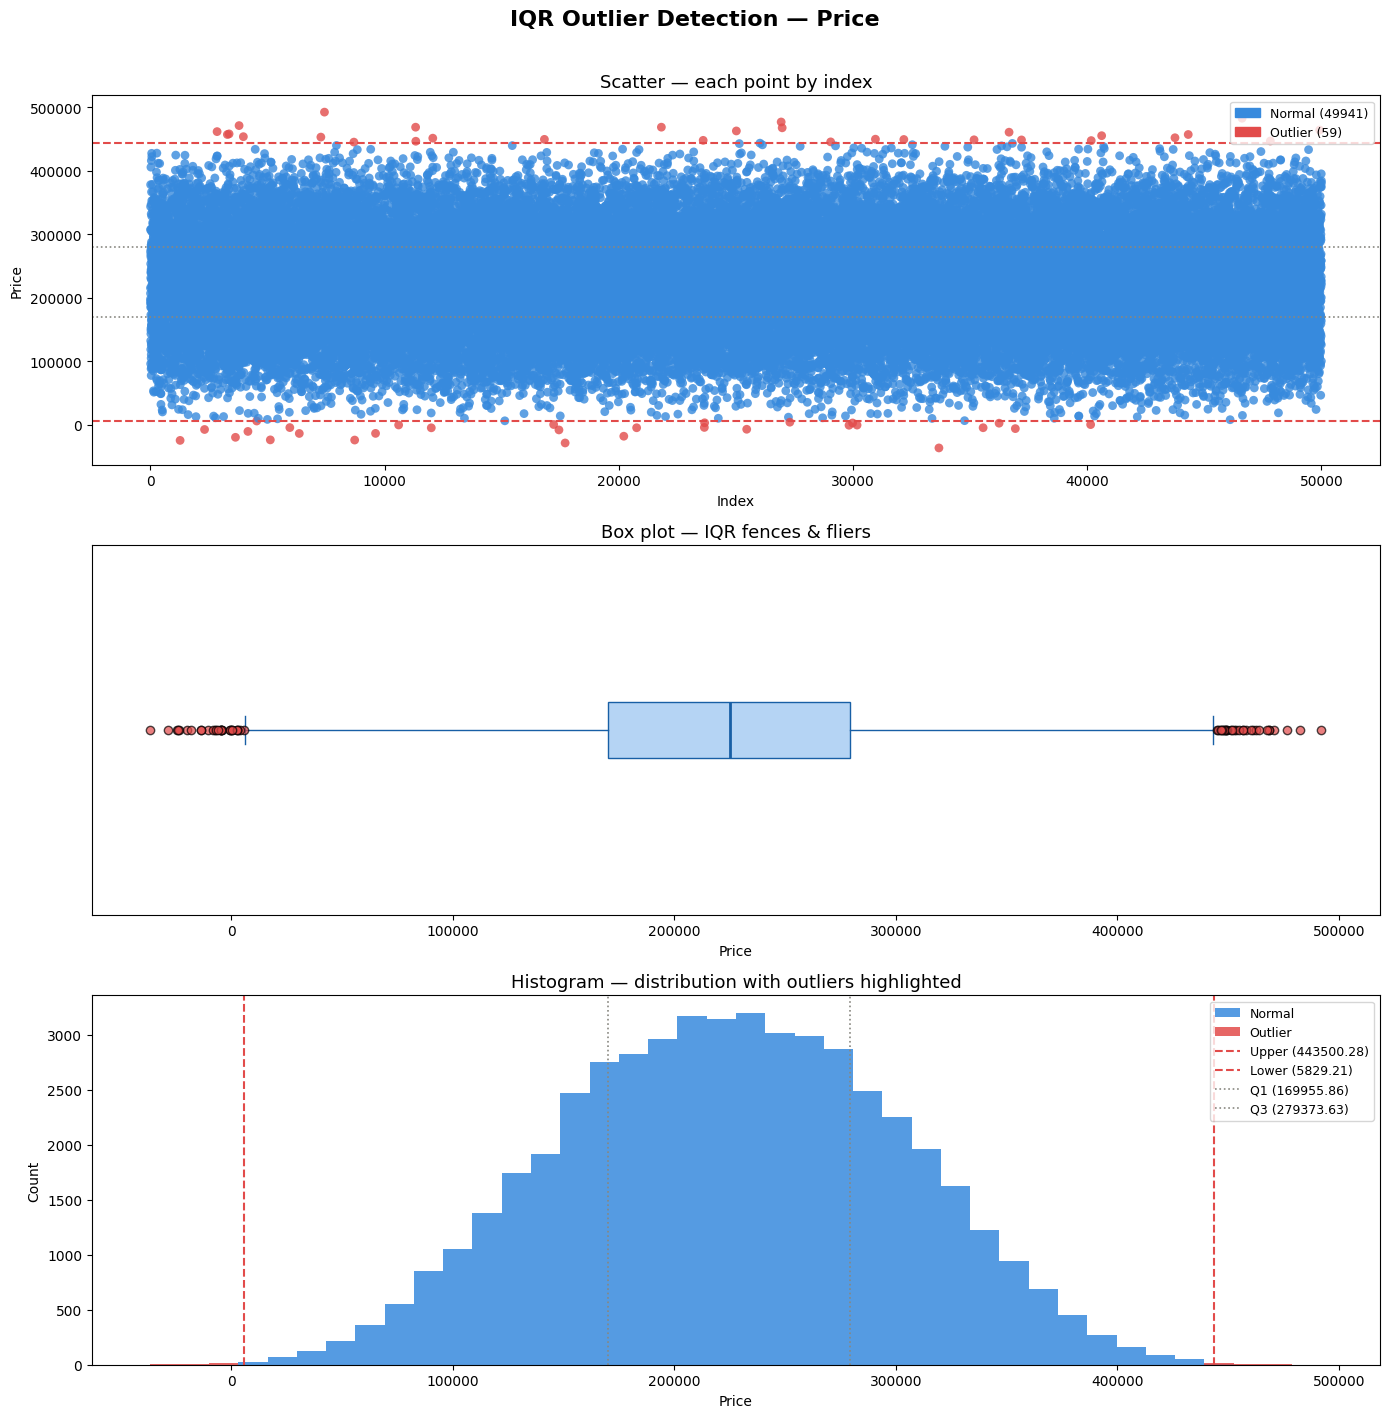

In [39]:

Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Price"] < lower) | (df["Price"] > upper)]

colors = ["#E24B4A" if v < lower or v > upper else "#378ADD" for v in df["Price"]]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle("IQR Outlier Detection — Price", fontsize=16, fontweight="bold", y=1.01)

ax1 = axes[0]
ax1.scatter(range(len(df)), df["Price"], c=colors, s=40, alpha=0.8, linewidths=0)
ax1.axhline(upper, color="#E24B4A", linestyle="--", linewidth=1.5, label=f"Upper fence ({upper:.2f})")
ax1.axhline(lower, color="#E24B4A", linestyle="--", linewidth=1.5, label=f"Lower fence ({lower:.2f})")
ax1.axhline(Q3,    color="#888780", linestyle=":",  linewidth=1.2, label=f"Q3 ({Q3:.2f})")
ax1.axhline(Q1,    color="#888780", linestyle=":",  linewidth=1.2, label=f"Q1 ({Q1:.2f})")
ax1.set_title("Scatter — each point by index", fontsize=13)
ax1.set_xlabel("Index")
ax1.set_ylabel("Price")
ax1.legend(fontsize=9)
normal_patch  = mpatches.Patch(color="#378ADD", label=f"Normal ({len(df) - len(outliers)})")
outlier_patch = mpatches.Patch(color="#E24B4A", label=f"Outlier ({len(outliers)})")
ax1.legend(handles=[normal_patch, outlier_patch], fontsize=9, loc="upper right")

ax2 = axes[1]
bp = ax2.boxplot(df["Price"].dropna(), vert=False, patch_artist=True,
                 flierprops=dict(marker="o", color="#E24B4A", markerfacecolor="#E24B4A",
                                 markersize=6, alpha=0.7),
                 boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
                 medianprops=dict(color="#185FA5", linewidth=2),
                 whiskerprops=dict(color="#185FA5"),
                 capprops=dict(color="#185FA5"))
ax2.set_title("Box plot — IQR fences & fliers", fontsize=13)
ax2.set_xlabel("Price")
ax2.set_yticks([])


ax3 = axes[2]
normal_vals  = df.loc[(df["Price"] >= lower) & (df["Price"] <= upper), "Price"]
outlier_vals = df.loc[(df["Price"] <  lower) | (df["Price"] >  upper), "Price"]

bins = np.histogram_bin_edges(df["Price"].dropna(), bins=40)
ax3.hist(normal_vals,  bins=bins, color="#378ADD", alpha=0.85, label="Normal")
ax3.hist(outlier_vals, bins=bins, color="#E24B4A", alpha=0.85, label="Outlier")
ax3.axvline(upper, color="#E24B4A", linestyle="--", linewidth=1.5, label=f"Upper ({upper:.2f})")
ax3.axvline(lower, color="#E24B4A", linestyle="--", linewidth=1.5, label=f"Lower ({lower:.2f})")
ax3.axvline(Q1,    color="#888780", linestyle=":",  linewidth=1.2, label=f"Q1 ({Q1:.2f})")
ax3.axvline(Q3,    color="#888780", linestyle=":",  linewidth=1.2, label=f"Q3 ({Q3:.2f})")
ax3.set_title("Histogram — distribution with outliers highlighted", fontsize=13)
ax3.set_xlabel("Price")
ax3.set_ylabel("Count")
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig("iqr_outliers.png", dpi=150, bbox_inches="tight")
plt.show()



**Visualization of the outlier using Boxplot ,scatterplot and histogram**

In [43]:
df["SquareFeet"] = pd.to_numeric(df["SquareFeet"] , errors = "coerce")
df["Beedrooms"] = pd.to_numeric(df["Bedrooms"], errors = "coerce")
df["Bathrooms"] = pd.to_numeric(df["Bathrooms"], errors="coerce")
df["YearBuilt"] = pd.to_numeric(df["YearBuilt"], errors = "coerce")
df["Price"] = pd.to_numeric(df["Price"], errors = "coerce")
df["Neighborhood"] = df["Neighborhood"].astype("category")

df["Neighborhood"] = df["Neighborhood"].str.strip()
print(df.dtypes)

SquareFeet        int64
Bedrooms          int64
Bathrooms         int64
Neighborhood     object
YearBuilt         int64
Price           float64
Beedrooms         int64
dtype: object


Data Types & Cleaning